# CIFAR-10 Latest Robustness Layer Analysis

This notebook compares the latest CIFAR-10 Spatial Functa experiments under the same inner-5 PGD protocol used in the robustness runs.

It is designed to answer three questions:

1. Do the constrained SIREN backbones reduce adversarial activation differences compared with vanilla?
2. Do constrained layers have smaller clean activation norms?
3. Which layers amplify perturbations the most?

The notebook discovers completed runs from:

- `runs/cifar10_spatial_inner5_make5_clfbest_v1`
- `runs/cifar10_spatial_inner5_warmstart_models`
- `runs/cifar10_spatial_inner5_softlip_warmstart_caps`

A run is included in PGD-paired analysis only if it has both a SIREN checkpoint and a matching CNN classifier checkpoint. Incomplete runs, such as the current 90 percent readout-cap inner-5 run, are shown in the manifest as missing rather than silently analyzed with the wrong classifier.

## Cell 1: Configuration

This cell controls the analysis budget. The defaults use the same PGD settings as the corrected robustness evaluations: `mod_steps=5`, `inner_lr=0.01`, `pgd_steps=200`, `pgd_lr=0.01`, and no clean/final phi gradient clipping. Only `N_SAMPLES` is intentionally small because this notebook compares many models and stores layer activations.

In [ ]:
from pathlib import Path

REPO_ROOT = Path('/home/omarg/SIREN_Vista')
DATA_PATH = Path('/home/omarg/data')

RUN_ROOTS = [
    REPO_ROOT / 'runs/cifar10_spatial_inner5_make5_clfbest_v1',
    REPO_ROOT / 'runs/cifar10_spatial_inner5_warmstart_models',
    REPO_ROOT / 'runs/cifar10_spatial_inner5_softlip_warmstart_caps',
]

OUT_DIR = REPO_ROOT / 'runs/diagnostics/cifar10_latest_robustness_layer_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Same attack/fitting settings as the corrected matched inner-5 PGD runs.
EPSILON_255 = 4
PGD_STEPS = 200
PGD_LR = 0.01
INNER_STEPS = 5
INNER_LR = 0.01
CLEAN_GRAD_CLIP = 0.0
SEED = 0

# Keep this small first. Increase after the code path is verified.
N_SAMPLES = 16

# Set to a list of run labels to analyze a subset, or None for all complete runs.
# Example: MODEL_INCLUDE = ['vanilla_e512', 'softlip_tiered_e12', 'warm_readout_cap10_lam1']
MODEL_INCLUDE = None
MODEL_EXCLUDE = []

# Reuse saved CSVs if this exact configuration was already run.
REUSE_SAVED = True
CAPTURE_CLASSIFIER_LAYERS = True

RUN_TAG = f'eps{EPSILON_255}_n{N_SAMPLES}_pgd{PGD_STEPS}_inner{INNER_STEPS}'
METRICS_CSV = OUT_DIR / f'layer_metrics_{RUN_TAG}.csv'
SUMMARY_CSV = OUT_DIR / f'attack_summary_{RUN_TAG}.csv'
SIGMAS_CSV = OUT_DIR / 'checkpoint_sigmas_manifest.csv'

print('output:', OUT_DIR)
print('run tag:', RUN_TAG)

## Cell 2: Imports And Shared Loaders

This cell imports the same loader code used by `attacks/full_pgd_cifar10_spatial.py`. That matters because it keeps model construction, classifier normalization, and the inner-loop phi fitting path aligned with the PGD evaluations.

In [ ]:
import gc
import json
import math
import os
import re
import sys
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display

repo = str(REPO_ROOT.resolve())
if repo not in sys.path:
    sys.path.insert(0, repo)

from dataloader import get_cifar10_loader
from train_classifier import _prepare_modulations
from utils import set_random_seeds
from attacks.full_pgd_cifar10_spatial import (
    FullPGDCIFAR10Spatial,
    apply_classifier,
    check_model_classifier_compat,
    load_classifier_checkpoint,
    load_inr_checkpoint,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
set_random_seeds(SEED, DEVICE)
print('device:', DEVICE)
if DEVICE == 'cuda':
    print('gpu:', torch.cuda.get_device_name(0))

## Cell 3: Discover Completed And Incomplete Runs

This cell builds a manifest from `run_config.md` files. Complete rows have a SIREN checkpoint and classifier checkpoint. Incomplete rows are displayed separately so we can see, for example, whether a 90 percent cap exists but lacks a classifier/PGD run.

In [ ]:
def resolve_path(value):
    if value is None or value == '':
        return None
    path = Path(value)
    return path if path.is_absolute() else REPO_ROOT / path


def parse_run_config(path):
    text = path.read_text(errors='replace')

    def field(name):
        pattern = rf'- {re.escape(name)}:\s*`([^`]+)`'
        match = re.search(pattern, text)
        return match.group(1).strip() if match else None

    return {
        'run_label': path.parent.name,
        'run_root': path.parent,
        'config_path': path,
        'siren_checkpoint': resolve_path(field('SIREN checkpoint')),
        'classifier_checkpoint': resolve_path(field('classifier checkpoint')),
        'functaset_test': resolve_path(field('functaset test')),
        'pgd_mod_steps': field('PGD mod steps'),
        'pgd_steps': field('PGD steps'),
        'pgd_lr': field('PGD LR'),
        'pgd_eps_list': field('PGD eps list'),
        'pgd_max_samples': field('PGD max samples'),
    }


rows = []
seen_dirs = set()
for root in RUN_ROOTS:
    for cfg in sorted(root.glob('*/run_config.md')):
        rec = parse_run_config(cfg)
        rec['source_root'] = root.name
        rec['has_siren'] = rec['siren_checkpoint'] is not None and rec['siren_checkpoint'].is_file()
        rec['has_classifier'] = rec['classifier_checkpoint'] is not None and rec['classifier_checkpoint'].is_file()
        rec['complete_for_pgd_analysis'] = bool(rec['has_siren'] and rec['has_classifier'])
        rec['missing_reason'] = ''
        if not rec['has_siren']:
            rec['missing_reason'] += 'missing SIREN checkpoint; '
        if not rec['has_classifier']:
            rec['missing_reason'] += 'missing classifier checkpoint; '
        rows.append(rec)
        seen_dirs.add(cfg.parent)

    for run_dir in sorted(p for p in root.iterdir() if p.is_dir() and p.name != 'logs'):
        if run_dir in seen_dirs:
            continue
        rows.append({
            'run_label': run_dir.name,
            'run_root': run_dir,
            'config_path': None,
            'siren_checkpoint': None,
            'classifier_checkpoint': None,
            'functaset_test': None,
            'source_root': root.name,
            'has_siren': False,
            'has_classifier': False,
            'complete_for_pgd_analysis': False,
            'missing_reason': 'missing run_config.md; missing classifier checkpoint; ',
        })

# Known incomplete 90 percent readout-cap backbone: useful to see in the manifest,
# but excluded from PGD-paired analysis until an inner-5 classifier exists.
cap90_ckpt = REPO_ROOT / 'model_cifar10/cifar10_spatial_warmvanilla_readout_cap90_lam1.0/modSiren.pth'
mask = [r['run_label'] == 'warm_readout_cap90_lam1' for r in rows]
if any(mask):
    rec = rows[mask.index(True)]
    rec['siren_checkpoint'] = cap90_ckpt if cap90_ckpt.is_file() else None
    rec['has_siren'] = cap90_ckpt.is_file()
    rec['missing_reason'] = 'missing run_config/classifier/PGD under the requested run roots; backbone exists; '

manifest = pd.DataFrame(rows)
complete_manifest = manifest[manifest['complete_for_pgd_analysis']].copy()
if MODEL_INCLUDE is not None:
    complete_manifest = complete_manifest[complete_manifest['run_label'].isin(MODEL_INCLUDE)]
if MODEL_EXCLUDE:
    complete_manifest = complete_manifest[~complete_manifest['run_label'].isin(MODEL_EXCLUDE)]

display_cols = ['run_label', 'source_root', 'complete_for_pgd_analysis', 'has_siren', 'has_classifier', 'missing_reason']
display(manifest[display_cols].sort_values(['complete_for_pgd_analysis', 'source_root', 'run_label'], ascending=[False, True, True]))
print('complete runs selected:', len(complete_manifest))
display(complete_manifest[['run_label', 'siren_checkpoint', 'classifier_checkpoint']].sort_values('run_label'))

## Cell 4: Checkpoint Sigma Sanity Check

This cell computes exact SVD singular values for every selected checkpoint. These values are not the main activation analysis, but they tell us whether spectral constraints changed the actual weights. The product bound is the usual loose SIREN upper bound: product over `freq * sigma(sine_i)`, then multiplied by the readout sigma.

In [ ]:
def exact_sigma(weight):
    w = weight.detach().float().reshape(weight.shape[0], -1)
    return float(torch.linalg.svdvals(w)[0].item())


def checkpoint_sigma_record(label, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location='cpu')
    state = ckpt.get('state_dict', ckpt)
    model_args = ckpt.get('model_args', {}) or {}
    freq = float(model_args.get('freq', 10.0))
    rec = {
        'run_label': label,
        'model_name': ckpt.get('model_name'),
        'variant': ckpt.get('variant', 'vanilla'),
        'best_epoch': ckpt.get('epoch'),
        'best_loss': ckpt.get('loss'),
    }
    product = 1.0
    i = 0
    while f'siren.net.{i}.affine.weight' in state:
        sig = exact_sigma(state[f'siren.net.{i}.affine.weight'])
        rec[f'sine_{i}_sigma'] = sig
        product *= max(freq * sig, 1e-12)
        i += 1
    if 'siren.hidden2rgb.weight' in state:
        readout = exact_sigma(state['siren.hidden2rgb.weight'])
        rec['readout_sigma'] = readout
        product *= readout
    rec['product_bound'] = product
    va = ckpt.get('variant_args', {}) or {}
    rec.update({f'variant_{k}': v for k, v in va.items() if isinstance(v, (str, int, float, bool, type(None)))})
    return rec


sigma_rows = []
for row in complete_manifest.itertuples(index=False):
    sigma_rows.append(checkpoint_sigma_record(row.run_label, row.siren_checkpoint))

# Also include the incomplete cap90 backbone if present, marked as clean-only.
if cap90_ckpt.is_file() and 'warm_readout_cap90_lam1' not in set(complete_manifest['run_label']):
    rec = checkpoint_sigma_record('warm_readout_cap90_lam1__no_classifier', cap90_ckpt)
    rec['note'] = 'backbone exists, no matching inner-5 classifier in requested run roots'
    sigma_rows.append(rec)

sigma_df = pd.DataFrame(sigma_rows)
sigma_df.to_csv(SIGMAS_CSV, index=False)
display(sigma_df[['run_label', 'variant', 'best_epoch', 'best_loss', 'sine_5_sigma', 'readout_sigma', 'product_bound']].sort_values('run_label'))
print('saved:', SIGMAS_CSV)

## Cell 5: PGD And Activation Capture Helpers

This cell defines the actual analysis machinery. For each sample and model, it creates a PGD adversarial image using the same inner-5 attack path. Then it refits clean phi and adversarial phi, runs both through the INR, and records:

- clean activation norm per layer
- adversarial minus clean activation difference per layer
- difference normalized by the image perturbation norm
- layer-by-layer amplification ratio, where values above 1 indicate amplification

In [ ]:
criterion = nn.CrossEntropyLoss().to(DEVICE)


def short_label(label):
    replacements = {
        'vanilla_e512': 'vanilla',
        'softlip_tiered_e12': 'softlip tiered',
        'warm_readout_cap10_lam1': 'vanilla readout 10%',
        'warm_readout_cap50_lam1': 'vanilla readout 50%',
        'warm_readout_cap90_lam1': 'vanilla readout 90%',
        'warm_prereadout_cap10_lam1': 'vanilla last-sine 10%',
        'warm_orth_lam1e-3': 'vanilla orth',
        'warm_readout_counter1_lam1e-2': 'vanilla readout counter',
        'warm_prereadout_counter1_lam1e-2': 'vanilla last-sine counter',
        'warmsoftlip_readout_cap50_lam1.0_e5': 'softlip readout 50%',
        'warmsoftlip_readout_cap10_lam1.0_e5': 'softlip readout 10%',
        'warmsoftlip_prereadout_cap50_lam1.0_e5': 'softlip last-sine 50%',
        'warmsoftlip_prereadout_cap10_lam1.0_e5': 'softlip last-sine 10%',
    }
    return replacements.get(label, label)


def tensor_l2(x):
    return float(x.detach().float().reshape(-1).norm().cpu().item())


def generate_adversarial_pair(attack_model, x, y, epsilon):
    x = x.to(DEVICE).float()
    y = y.to(DEVICE).long()

    clean_logits, clean_phi, clean_mse = attack_model(x, clean=True, return_mse=True)
    clean_pred = int(clean_logits.argmax(1).item())

    pert = torch.zeros_like(x[0], device=DEVICE, requires_grad=True)
    optimizer = optim.Adam([pert], lr=PGD_LR)
    for _ in range(PGD_STEPS):
        optimizer.zero_grad(set_to_none=True)
        proj_pert = torch.clamp(pert, -epsilon, epsilon)
        adv_x = torch.clamp(x + proj_pert.unsqueeze(0), 0.0, 1.0)
        logits, _ = attack_model(adv_x, clean_phi.detach(), clean=False)
        loss = -criterion(logits, y)
        loss.backward()
        optimizer.step()

    final_pert = torch.clamp(pert.detach(), -epsilon, epsilon)
    final_x = torch.clamp(x + final_pert.unsqueeze(0), 0.0, 1.0)
    adv_logits, adv_phi, adv_mse = attack_model(final_x, clean_phi.detach(), clean=True, return_mse=True)
    adv_pred = int(adv_logits.argmax(1).item())

    return {
        'x': x.detach(),
        'y': y.detach(),
        'adv_x': final_x.detach(),
        'pert': final_pert.detach(),
        'clean_phi': clean_phi.detach(),
        'adv_phi': adv_phi.detach(),
        'clean_logits': clean_logits.detach(),
        'adv_logits': adv_logits.detach(),
        'clean_pred': clean_pred,
        'adv_pred': adv_pred,
        'clean_mse': clean_mse,
        'adv_mse': adv_mse,
        'delta_norm': tensor_l2(final_pert),
    }


def capture_inr_activations(inr, phi_batch):
    phi = phi_batch[0].to(DEVICE).float()
    activations = OrderedDict()
    activations['phi'] = phi.detach().cpu()
    handles = []

    def hook_for(name):
        def hook(module, inputs, output):
            activations[name] = output.detach().cpu()
        return hook

    for i, layer in enumerate(inr.siren.net):
        handles.append(layer.register_forward_hook(hook_for(f'sine_{i}')))
    handles.append(inr.siren.hidden2rgb.register_forward_hook(hook_for('readout_rgb')))
    with torch.no_grad():
        _ = inr(phi)
    for handle in handles:
        handle.remove()
    return activations


def classifier_input_tensor(classifier, phi_batch):
    x = _prepare_modulations(
        phi_batch,
        classifier_type=getattr(classifier, '_clf_type', 'mlp'),
        latent_spatial_dim=getattr(classifier, '_latent_spatial_dim', None),
        latent_dim=getattr(classifier, '_latent_dim', None),
    )
    if getattr(classifier, '_phi_mean', None) is not None and getattr(classifier, '_phi_std', None) is not None:
        x = (x - classifier._phi_mean) / classifier._phi_std
    return x


def capture_classifier_activations(classifier, phi_batch):
    activations = OrderedDict()
    x = classifier_input_tensor(classifier, phi_batch.to(DEVICE).float())
    activations['classifier_input'] = x.detach().cpu()
    handles = []

    def hook_for(name):
        def hook(module, inputs, output):
            if torch.is_tensor(output):
                activations[name] = output.detach().cpu()
        return hook

    for name, module in classifier.named_modules():
        if name == '':
            continue
        if len(list(module.children())) == 0:
            handles.append(module.register_forward_hook(hook_for(name)))
    with torch.no_grad():
        _ = classifier(x)
    for handle in handles:
        handle.remove()
    return activations


def metric_rows_from_activations(model_label, sample_id, scope, clean_acts, adv_acts, delta_norm):
    rows = []
    previous_diff = None
    for layer_index, (layer, clean_act) in enumerate(clean_acts.items()):
        if layer not in adv_acts:
            continue
        adv_act = adv_acts[layer]
        diff = tensor_l2(adv_act - clean_act)
        clean_norm = tensor_l2(clean_act)
        adv_norm = tensor_l2(adv_act)
        if previous_diff is None:
            ratio = diff / max(delta_norm, 1e-12)
            ratio_denominator = 'image_delta_l2'
        else:
            ratio = diff / max(previous_diff, 1e-12)
            ratio_denominator = 'previous_layer_diff'
        rows.append({
            'model_label': model_label,
            'model_short': short_label(model_label),
            'sample_id': sample_id,
            'scope': scope,
            'layer_index': layer_index,
            'layer': layer,
            'clean_activation_norm': clean_norm,
            'adv_activation_norm': adv_norm,
            'diff_norm': diff,
            'diff_over_image_delta': diff / max(delta_norm, 1e-12),
            'layer_amplification_ratio': ratio,
            'ratio_denominator': ratio_denominator,
        })
        previous_diff = diff
    return rows

## Cell 6: Run The PGD-Paired Layer Analysis

This is the expensive cell. It loops over selected models and the first `N_SAMPLES` CIFAR-10 test images. For each model/image pair it generates an adversarial image, refits final adversarial phi with the same non-clipped clean refit used by the patched PGD script, and records INR plus optional classifier activations.

In [ ]:
def run_layer_analysis():
    epsilon = EPSILON_255 / 255.0
    loader = get_cifar10_loader(
        str(DATA_PATH),
        train=False,
        batch_size=1,
        num_workers=0,
        pin_memory=False,
    )
    all_metric_rows = []
    attack_rows = []

    for model_idx, row in enumerate(complete_manifest.sort_values('run_label').itertuples(index=False), start=1):
        label = row.run_label
        print(f'[{model_idx}/{len(complete_manifest)}] loading {label}')
        inr, inr_ckpt = load_inr_checkpoint(str(row.siren_checkpoint), DEVICE)
        classifier, clf_ckpt = load_classifier_checkpoint(str(row.classifier_checkpoint), DEVICE)
        check_model_classifier_compat(inr, classifier)
        attack_model = FullPGDCIFAR10Spatial(
            inr,
            classifier,
            inner_steps=INNER_STEPS,
            inner_lr=INNER_LR,
            clean_grad_clip=CLEAN_GRAD_CLIP,
            device=DEVICE,
        ).to(DEVICE)

        for sample_id, (x, y) in enumerate(loader):
            if sample_id >= N_SAMPLES:
                break
            pair = generate_adversarial_pair(attack_model, x, y, epsilon)
            label_int = int(pair['y'].item())
            clean_correct = int(pair['clean_pred'] == label_int)
            adv_correct = int(pair['adv_pred'] == label_int)
            attack_rows.append({
                'model_label': label,
                'model_short': short_label(label),
                'sample_id': sample_id,
                'label': label_int,
                'clean_pred': pair['clean_pred'],
                'adv_pred': pair['adv_pred'],
                'clean_correct': clean_correct,
                'adv_correct': adv_correct,
                'clean_mse': pair['clean_mse'],
                'adv_mse': pair['adv_mse'],
                'delta_norm': pair['delta_norm'],
                'epsilon_255': EPSILON_255,
                'pgd_steps': PGD_STEPS,
                'inner_steps': INNER_STEPS,
            })

            clean_inr = capture_inr_activations(inr, pair['clean_phi'])
            adv_inr = capture_inr_activations(inr, pair['adv_phi'])
            all_metric_rows.extend(metric_rows_from_activations(label, sample_id, 'inr', clean_inr, adv_inr, pair['delta_norm']))

            if CAPTURE_CLASSIFIER_LAYERS:
                clean_clf = capture_classifier_activations(classifier, pair['clean_phi'])
                adv_clf = capture_classifier_activations(classifier, pair['adv_phi'])
                all_metric_rows.extend(metric_rows_from_activations(label, sample_id, 'classifier', clean_clf, adv_clf, pair['delta_norm']))

            if (sample_id + 1) % 4 == 0 or sample_id + 1 == N_SAMPLES:
                print(f'  {label}: {sample_id + 1}/{N_SAMPLES} samples')

        del attack_model, classifier, inr
        gc.collect()
        if DEVICE == 'cuda':
            torch.cuda.empty_cache()

    metrics_df = pd.DataFrame(all_metric_rows)
    summary_df = pd.DataFrame(attack_rows)
    metrics_df.to_csv(METRICS_CSV, index=False)
    summary_df.to_csv(SUMMARY_CSV, index=False)
    return metrics_df, summary_df


if REUSE_SAVED and METRICS_CSV.is_file() and SUMMARY_CSV.is_file():
    metrics_df = pd.read_csv(METRICS_CSV)
    summary_df = pd.read_csv(SUMMARY_CSV)
    print('loaded saved metrics:', METRICS_CSV)
else:
    metrics_df, summary_df = run_layer_analysis()
    print('saved metrics:', METRICS_CSV)
    print('saved summary:', SUMMARY_CSV)

display(summary_df.groupby(['model_label', 'model_short']).agg(
    n=('sample_id', 'count'),
    clean_acc=('clean_correct', 'mean'),
    adv_acc=('adv_correct', 'mean'),
    mean_delta_l2=('delta_norm', 'mean'),
    mean_clean_mse=('clean_mse', 'mean'),
    mean_adv_mse=('adv_mse', 'mean'),
).reset_index().sort_values('adv_acc', ascending=False))

## Cell 7: Average Metrics Across Samples

This cell averages the raw per-sample layer measurements. The resulting table is the main data behind the figures.

In [ ]:
avg_df = (
    metrics_df
    .groupby(['scope', 'model_label', 'model_short', 'layer_index', 'layer'], as_index=False)
    .agg(
        clean_activation_norm=('clean_activation_norm', 'mean'),
        adv_activation_norm=('adv_activation_norm', 'mean'),
        diff_norm=('diff_norm', 'mean'),
        diff_over_image_delta=('diff_over_image_delta', 'mean'),
        layer_amplification_ratio=('layer_amplification_ratio', 'mean'),
    )
)
AVG_CSV = OUT_DIR / f'layer_metrics_average_{RUN_TAG}.csv'
avg_df.to_csv(AVG_CSV, index=False)
display(avg_df.head(20))
print('saved:', AVG_CSV)

## Cell 8: Figure 1 - Adversarial Activation Difference Across Layers

This is the closest plot to the requested Figure 5-style analysis. The y-axis is the mean L2 difference between clean and adversarial activations at each layer. If a constrained model truly attenuates perturbations, its curve should sit below vanilla at the relevant layers.

In [ ]:
def plot_metric(scope, metric, ylabel, filename, logy=False):
    sub = avg_df[avg_df['scope'] == scope].copy()
    if sub.empty:
        print('no rows for scope:', scope)
        return
    fig, ax = plt.subplots(figsize=(13, 6))
    for label, group in sub.groupby('model_short'):
        group = group.sort_values('layer_index')
        ax.plot(group['layer_index'], group[metric], marker='o', linewidth=1.8, label=label)
    first = sub.sort_values('layer_index').drop_duplicates('layer_index')
    ax.set_xticks(first['layer_index'])
    ax.set_xticklabels(first['layer'], rotation=35, ha='right')
    ax.set_xlabel('layer')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{scope}: {ylabel}')
    if logy:
        ax.set_yscale('log')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
    fig.tight_layout()
    out = OUT_DIR / filename
    fig.savefig(out, dpi=180, bbox_inches='tight')
    print('saved:', out)
    plt.show()


plot_metric('inr', 'diff_norm', 'mean ||a_adv - a_clean||_2', f'inr_diff_norm_{RUN_TAG}.png', logy=True)
if CAPTURE_CLASSIFIER_LAYERS:
    plot_metric('classifier', 'diff_norm', 'mean ||h_adv - h_clean||_2', f'classifier_diff_norm_{RUN_TAG}.png', logy=True)

## Cell 9: Figure 2 - Difference Normalized By Input Perturbation

This plot divides each layer difference by the image perturbation L2 norm. It is useful when PGD projections or clipping cause slightly different effective perturbation norms across samples.

In [ ]:
plot_metric('inr', 'diff_over_image_delta', 'mean ||a_adv - a_clean||_2 / ||delta||_2', f'inr_diff_over_delta_{RUN_TAG}.png', logy=True)
if CAPTURE_CLASSIFIER_LAYERS:
    plot_metric('classifier', 'diff_over_image_delta', 'mean ||h_adv - h_clean||_2 / ||delta||_2', f'classifier_diff_over_delta_{RUN_TAG}.png', logy=True)

## Cell 10: Figure 3 - Clean Activation Norms

This is the constraint effectiveness sanity check. If a layer is really being constrained in a way that changes the representation, its clean activation norm may drop relative to vanilla. If the norms are unchanged, the constraint may not be affecting the forward signal much.

In [ ]:
plot_metric('inr', 'clean_activation_norm', 'mean ||a_clean||_2', f'inr_clean_activation_norm_{RUN_TAG}.png', logy=True)
if CAPTURE_CLASSIFIER_LAYERS:
    plot_metric('classifier', 'clean_activation_norm', 'mean ||h_clean||_2', f'classifier_clean_activation_norm_{RUN_TAG}.png', logy=True)

## Cell 11: Figure 4 - Layer-By-Layer Amplification Ratio

This plot computes `R_l = ||diff_l|| / ||diff_{l-1}||`. For the first row in each scope, the denominator is the image perturbation norm. Values above 1 mean that layer increased the perturbation difference relative to the previous layer; values below 1 mean attenuation.

In [ ]:
plot_metric('inr', 'layer_amplification_ratio', 'mean layer amplification ratio', f'inr_layer_amplification_ratio_{RUN_TAG}.png', logy=True)
if CAPTURE_CLASSIFIER_LAYERS:
    plot_metric('classifier', 'layer_amplification_ratio', 'mean layer amplification ratio', f'classifier_layer_amplification_ratio_{RUN_TAG}.png', logy=True)

## Cell 12: Tables For Reading Exact Values

The plots are easier to read visually, but the tables below are better for comparing specific layers such as the final sine layer or readout. Use these tables to answer whether the cap changed the layer where it was supposed to act.

In [ ]:
def pivot_metric(scope, metric):
    sub = avg_df[avg_df['scope'] == scope]
    table = sub.pivot_table(index='model_short', columns='layer', values=metric, aggfunc='mean')
    ordered_layers = sub.sort_values('layer_index')['layer'].drop_duplicates().tolist()
    return table.reindex(columns=ordered_layers)


print('INR mean activation difference')
display(pivot_metric('inr', 'diff_norm'))

print('INR clean activation norm')
display(pivot_metric('inr', 'clean_activation_norm'))

print('INR amplification ratio')
display(pivot_metric('inr', 'layer_amplification_ratio'))

## Cell 13: Interpretation Checklist

Use the figures and tables above in this order:

1. Compare `inr_diff_norm`: if constrained models are not below vanilla, the constraint did not reduce adversarial representation movement.
2. Compare `inr_clean_activation_norm`: if clean norms are unchanged, the cap may be changing weights without changing the forward signal much.
3. Compare `inr_layer_amplification_ratio`: values above 1 show where the perturbation grows. If growth happens before the capped layer, late-layer caps are probably too late.
4. Compare classifier plots: if the INR differences look smaller but classifier differences grow, the downstream CNN may be the sensitive part.
5. Cross-check `checkpoint_sigmas_manifest.csv`: if a model did not actually reach its cap, treat its PGD result as an under-converged pressure experiment, not as evidence about that cap.

For thesis figures, rerun this notebook with a larger `N_SAMPLES` after the small default run produces sensible curves.

# Focused Four-Model Side-By-Side Comparison

This section compares exactly four models on identical CIFAR-10 samples:

1. **Vanilla**: the current e512 baseline.
2. **Single last-sine cap**: `warmsoftlip_prereadout_cap50_lam1.0_e5`. This is the latest single-layer model whose requested 50 percent final-sine cap nearly converged (`sigma/cap = 1.02`).
3. **Capped-all / tiered softlip**: the softlip tiered e12 model, which constrains the full sine stack and readout relative to vanilla.
4. **Most robust readout-targeted model**: `warm_readout_counter1_lam1e-2`. It had the strongest recorded PGD results among readout-targeted runs at eps 2, 4, and 6, but is marked provisional because its classifier training stopped around 70.2 percent.

The model labels are explicit in the next cell, so they can be changed if a different definition of "best last-layer model" is desired.

## Cell 14: Configure And Load The Three Models

**This cell is standalone.** You do not need to run any earlier notebook cells. Run this setup cell once, then run Cells 15-18 below.

The comparison uses direct checkpoint/classifier paths from the robustness evaluation. `CASE_EPSILON_255=1` is the runtime-friendly default because joint failed and joint successful attacks are both common enough to find without a long search. The attack still uses the exact PGD-200 and inner-5 fitting protocol.

In [1]:
# Standalone bootstrap for the focused four-model comparison.
from pathlib import Path
from collections import OrderedDict
import json
import math
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display

REPO_ROOT = Path('/home/omarg/SIREN_Vista')
DATA_PATH = Path('/home/omarg/data')
repo = str(REPO_ROOT.resolve())
if repo not in sys.path:
    sys.path.insert(0, repo)

from dataloader import get_cifar10_loader
from utils import set_random_seeds
from attacks.full_pgd_cifar10_spatial import (
    FullPGDCIFAR10Spatial,
    check_model_classifier_compat,
    load_classifier_checkpoint,
    load_inr_checkpoint,
)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
INNER_STEPS = 5
INNER_LR = 0.01
PGD_STEPS = 200
PGD_LR = 0.01
CLEAN_GRAD_CLIP = 0.0
SEED = 0
set_random_seeds(SEED, DEVICE)
criterion = nn.CrossEntropyLoss().to(DEVICE)

VANILLA_SLUG = 'functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e512_inner3_moptsgd_adamphi3_lr1e-02_train50000_test10000'
SOFTLIP_SLUG = 'functa_like_cifar10_spatial_paper_siren_h256_md1024_d6_lat8x16_freq10.0_nearest_lc_norm01_extlr3e-05_e12_inner3_moptsgd_adamphi3_lr1e-02_softlip_cifar_spatial_tiered_lam1e-02_sine_and_readout_train50000_test10000'

CASE_MODELS = OrderedDict([
    ('Vanilla', {
        'run_label': 'vanilla_e512',
        'siren_checkpoint': REPO_ROOT / 'model_cifar10' / VANILLA_SLUG / 'modSiren.pth',
        'classifier_checkpoint': REPO_ROOT / 'runs/cifar10_spatial_inner5_make5_clfbest_v1/vanilla_e512/cifar10_cnn_classifier_best_sweep_inner5/best_classifier.pth',
    }),
    ('Last-sine cap 50%', {
        'run_label': 'warmsoftlip_prereadout_cap50_lam1.0_e5',
        'siren_checkpoint': REPO_ROOT / 'model_cifar10/cifar10_spatial_warmsoftlip_prereadout_cap50_lam1.0_e5/modSiren.pth',
        'classifier_checkpoint': REPO_ROOT / 'runs/cifar10_spatial_inner5_softlip_warmstart_caps/warmsoftlip_prereadout_cap50_lam1.0_e5/cifar10_cnn_classifier_best_sweep_inner5/best_classifier.pth',
    }),
    ('Tiered cap all', {
        'run_label': 'softlip_tiered_e12',
        'siren_checkpoint': REPO_ROOT / 'model_cifar10' / SOFTLIP_SLUG / 'modSiren.pth',
        'classifier_checkpoint': REPO_ROOT / 'runs/cifar10_spatial_inner5_make5_clfbest_v1/softlip_tiered_e12/cifar10_cnn_classifier_best_sweep_inner5/best_classifier.pth',
    }),
    ('Readout counter (provisional)', {
        'run_label': 'warm_readout_counter1_lam1e-2',
        'siren_checkpoint': REPO_ROOT / 'model_cifar10/cifar10_spatial_warmvanilla_readout_counter1.0_lam1e-2/modSiren.pth',
        'classifier_checkpoint': REPO_ROOT / 'runs/cifar10_spatial_inner5_warmstart_models/warm_readout_counter1_lam1e-2/cifar10_cnn_classifier_best_sweep_inner5/best_classifier.pth',
    }),
])

CLEAN_SAMPLE_INDEX = 3
CASE_EPSILON_255 = 1
MAX_CASE_SEARCH = 60
CASE_CACHE_DIR = REPO_ROOT / 'runs/diagnostics/cifar10_latest_robustness_layer_analysis/focused_cases'
CASE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
CASE_INDEX_CACHE = CASE_CACHE_DIR / f'four_model_joint_cases_eps{CASE_EPSILON_255}_pgd{PGD_STEPS}_inner{INNER_STEPS}.json'
CASE_RESULT_CACHE = CASE_CACHE_DIR / f'four_model_joint_case_tensors_eps{CASE_EPSILON_255}_pgd{PGD_STEPS}_inner{INNER_STEPS}.pt'

# Set these to explicit CIFAR-10 test indices to skip automatic searching.
FAILED_ATTACK_SAMPLE_INDEX = None
SUCCEEDED_ATTACK_SAMPLE_INDEX = None


def load_case_model_bundles():
    bundles = OrderedDict()
    for display_name, config in CASE_MODELS.items():
        for key in ('siren_checkpoint', 'classifier_checkpoint'):
            if not config[key].is_file():
                raise FileNotFoundError(f"{display_name}: missing {key}: {config[key]}")
        inr, inr_ckpt = load_inr_checkpoint(str(config['siren_checkpoint']), DEVICE)
        classifier, clf_ckpt = load_classifier_checkpoint(str(config['classifier_checkpoint']), DEVICE)
        check_model_classifier_compat(inr, classifier)
        attack_model = FullPGDCIFAR10Spatial(
            inr,
            classifier,
            inner_steps=INNER_STEPS,
            inner_lr=INNER_LR,
            clean_grad_clip=CLEAN_GRAD_CLIP,
            device=DEVICE,
        ).to(DEVICE)
        bundles[display_name] = {
            'run_label': config['run_label'],
            'inr': inr,
            'classifier': classifier,
            'attack_model': attack_model,
            'inr_ckpt': inr_ckpt,
            'clf_ckpt': clf_ckpt,
        }
    return bundles


# Build the CIFAR-10 test dataset once. Recreating a DataLoader for every
# candidate was a large avoidable part of the original Cell 16 runtime.
CASE_TEST_DATASET = get_cifar10_loader(
    str(DATA_PATH), train=False, batch_size=1,
    num_workers=0, pin_memory=False,
).dataset


def get_cifar10_test_sample(sample_index):
    image, label = CASE_TEST_DATASET[sample_index]
    return image.unsqueeze(0), torch.tensor([label], dtype=torch.long)


def tensor_l2(tensor):
    return float(tensor.detach().float().reshape(-1).norm().cpu().item())


def activation_rms(tensor):
    tensor = tensor.detach().float()
    return float(torch.sqrt(torch.mean(tensor.pow(2))).cpu().item())


def capture_inr_activations(inr, phi_batch):
    phi = phi_batch[0].to(DEVICE).float()
    activations = OrderedDict()
    activations['phi'] = phi.detach().cpu()
    handles = []

    def hook_for(name):
        def hook(module, inputs, output):
            activations[name] = output.detach().cpu()
        return hook

    for index, layer in enumerate(inr.siren.net):
        handles.append(layer.register_forward_hook(hook_for(f'sine_{index}')))
    handles.append(inr.siren.hidden2rgb.register_forward_hook(hook_for('readout_rgb')))
    with torch.no_grad():
        _ = inr(phi)
    for handle in handles:
        handle.remove()
    return activations


def generate_adversarial_pair(attack_model, x, y, epsilon):
    x = x.to(DEVICE).float()
    y = y.to(DEVICE).long()
    clean_logits, clean_phi, clean_mse = attack_model(x, clean=True, return_mse=True)
    clean_pred = int(clean_logits.argmax(1).item())

    pert = torch.zeros_like(x[0], device=DEVICE, requires_grad=True)
    optimizer = optim.Adam([pert], lr=PGD_LR)
    for _ in range(PGD_STEPS):
        optimizer.zero_grad(set_to_none=True)
        projected = torch.clamp(pert, -epsilon, epsilon)
        attacked_x = torch.clamp(x + projected.unsqueeze(0), 0.0, 1.0)
        logits, _ = attack_model(attacked_x, clean_phi.detach(), clean=False)
        loss = -criterion(logits, y)
        loss.backward()
        optimizer.step()

    final_pert = torch.clamp(pert.detach(), -epsilon, epsilon)
    final_x = torch.clamp(x + final_pert.unsqueeze(0), 0.0, 1.0)
    adv_logits, adv_phi, adv_mse = attack_model(final_x, clean_phi.detach(), clean=True, return_mse=True)
    return {
        'x': x.detach(),
        'y': y.detach(),
        'adv_x': final_x.detach(),
        'pert': final_pert.detach(),
        'clean_phi': clean_phi.detach(),
        'adv_phi': adv_phi.detach(),
        'clean_logits': clean_logits.detach(),
        'adv_logits': adv_logits.detach(),
        'clean_pred': clean_pred,
        'adv_pred': int(adv_logits.argmax(1).item()),
        'clean_mse': clean_mse,
        'adv_mse': adv_mse,
        'delta_norm': tensor_l2(final_pert),
    }


case_models = load_case_model_bundles()
print('device:', DEVICE)
print('loaded:', list(case_models))

Files already downloaded and verified


device: cuda
loaded: ['Vanilla', 'Last-sine cap 50%', 'Tiered cap all', 'Readout counter (provisional)']


## Cell 15: Fit One Clean Sample Through All Four Models

This cell fits the same clean image independently with each INR using five SGD phi steps. It plots all reconstructions, reports exact reconstruction MSE and PSNR, and plots the RMS activation magnitude through `phi`, all six sine layers, and the RGB readout. This checks whether the single-layer, readout, or tiered constraints materially change the forward signal.

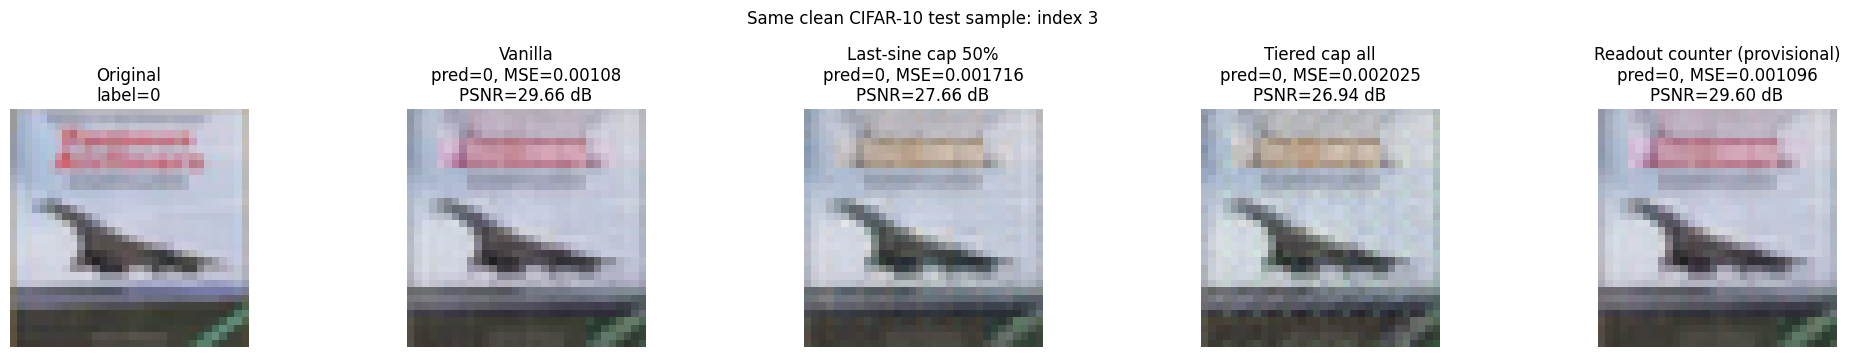

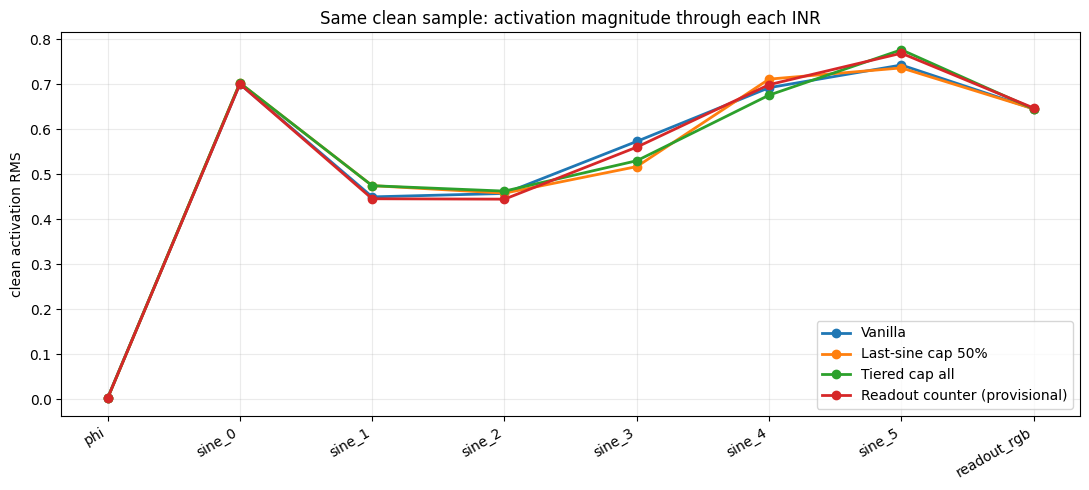

,model,prediction,reconstruction_mse,psnr_db,inner_loop_logged_mse,phi_rms,last_sine_rms,readout_rms
0,Vanilla,0,0.001080,29.664688,0.001103,0.002522,0.742277,0.644820
1,Last-sine cap 50%,0,0.001716,27.655816,0.001738,0.001627,0.735820,0.644756
2,Tiered cap all,0,0.002025,26.936616,0.002065,0.001613,0.776164,0.644728
3,Readout counter (provisional),0,0.001096,29.600104,0.001126,0.001552,0.768435,0.646635


In [2]:
clean_x, clean_y = get_cifar10_test_sample(CLEAN_SAMPLE_INDEX)
clean_x = clean_x.to(DEVICE).float()
clean_y = clean_y.to(DEVICE).long()
clean_comparison = OrderedDict()

for display_name, bundle in case_models.items():
    logits, phi, mse = bundle['attack_model'](clean_x, clean=True, return_mse=True)
    acts = capture_inr_activations(bundle['inr'], phi)
    with torch.no_grad():
        recon = bundle['inr'](phi[0]).reshape(32, 32, 3).permute(2, 0, 1).clamp(0, 1).cpu()
        target = clean_x[0].detach().cpu()
        reconstruction_mse = float(torch.mean((recon - target).pow(2)).item())
        psnr = 10.0 * math.log10(1.0 / max(reconstruction_mse, 1e-12))
    clean_comparison[display_name] = {
        'phi': phi,
        'logits': logits.detach(),
        'pred': int(logits.argmax(1).item()),
        'inner_loop_mse': mse,
        'reconstruction_mse': reconstruction_mse,
        'psnr': psnr,
        'activations': acts,
        'reconstruction': recon,
    }

fig, axes = plt.subplots(1, 1 + len(clean_comparison), figsize=(4 * (1 + len(clean_comparison)), 3.6))
axes[0].imshow(clean_x[0].detach().cpu().permute(1, 2, 0))
axes[0].set_title(f'Original\nlabel={int(clean_y.item())}')
axes[0].axis('off')
for ax, (display_name, result) in zip(axes[1:], clean_comparison.items()):
    ax.imshow(result['reconstruction'].permute(1, 2, 0))
    ax.set_title(
        f"{display_name}\npred={result['pred']}, "
        f"MSE={result['reconstruction_mse']:.4g}\nPSNR={result['psnr']:.2f} dB"
    )
    ax.axis('off')
fig.suptitle(f'Same clean CIFAR-10 test sample: index {CLEAN_SAMPLE_INDEX}')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for display_name, result in clean_comparison.items():
    layers = list(result['activations'])
    values = [activation_rms(result['activations'][layer]) for layer in layers]
    ax.plot(range(len(layers)), values, marker='o', linewidth=2, label=display_name)
ax.set_xticks(range(len(layers)))
ax.set_xticklabels(layers, rotation=30, ha='right')
ax.set_ylabel('clean activation RMS')
ax.set_title('Same clean sample: activation magnitude through each INR')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

display(pd.DataFrame([
    {
        'model': name,
        'prediction': result['pred'],
        'reconstruction_mse': result['reconstruction_mse'],
        'psnr_db': result['psnr'],
        'inner_loop_logged_mse': result['inner_loop_mse'],
        'phi_rms': activation_rms(result['activations']['phi']),
        'last_sine_rms': activation_rms(result['activations']['sine_5']),
        'readout_rms': activation_rms(result['activations']['readout_rgb']),
    }
    for name, result in clean_comparison.items()
]))

## Cell 16: Find A Shared Failed Attack And Shared Successful Attack

Definitions used here:

- **Failed attack on all four**: all models classify the clean sample correctly and all remain correct after their own PGD attack.
- **Successful attack on all four**: all models classify the clean sample correctly and all are wrong after their own PGD attack.

The CIFAR-10 test index is identical across models. Each model receives its own white-box PGD perturbation, because that is the fair way to test each composed pipeline. Results are cached in memory so a sample is not attacked twice during the search.

In [3]:
# Cell 16 optimization strategy:
# 1. Reuse one in-memory CIFAR-10 dataset from Cell 14.
# 2. Reject samples unless all four clean predictions are correct.
# 3. Search failed and successful cases in the same pass.
# 4. Do not run activation hooks while searching.
# 5. Stop a candidate as soon as it cannot satisfy its current branch.
# 6. Cache the two discovered test indices on disk for instant reruns.
joint_case_cache = {}
clean_screen_cache = {}


def screen_joint_clean_correct(sample_index):
    if sample_index in clean_screen_cache:
        return clean_screen_cache[sample_index]
    x, y = get_cifar10_test_sample(sample_index)
    label = int(y.item())
    for display_name, bundle in case_models.items():
        logits, _, _ = bundle['attack_model'](x.to(DEVICE), clean=True, return_mse=True)
        if int(logits.argmax(1).item()) != label:
            clean_screen_cache[sample_index] = False
            return False
    clean_screen_cache[sample_index] = True
    return True


def attack_candidate(sample_index, desired_case=None, allowed_cases=None):
    """Attack one clean-correct sample; omit hooks until a case is accepted."""
    x, y = get_cifar10_test_sample(sample_index)
    label = int(y.item())
    epsilon = CASE_EPSILON_255 / 255.0
    results = OrderedDict()
    active_case = desired_case

    # Start with the provisional readout model because it had the highest
    # robust accuracy. Its result usually rejects one branch immediately.
    model_order = ['Readout counter (provisional)', 'Vanilla', 'Last-sine cap 50%', 'Tiered cap all']
    for model_position, display_name in enumerate(model_order):
        bundle = case_models[display_name]
        pair = generate_adversarial_pair(bundle['attack_model'], x, y, epsilon)
        results[display_name] = pair
        adv_correct = pair['adv_pred'] == label
        if model_position == 0 and active_case is None:
            active_case = 'failed' if adv_correct else 'succeeded'
            if allowed_cases is not None and active_case not in allowed_cases:
                return None
        if active_case == 'failed' and not adv_correct:
            return None
        if active_case == 'succeeded' and adv_correct:
            return None

    return {'sample_index': sample_index, 'x': x, 'y': y, 'results': results, 'case_type': active_case}


def add_case_activations(record):
    for display_name, pair in record['results'].items():
        bundle = case_models[display_name]
        pair['clean_activations'] = capture_inr_activations(bundle['inr'], pair['clean_phi'])
        pair['adv_activations'] = capture_inr_activations(bundle['inr'], pair['adv_phi'])
    return record


def load_cached_case_indices():
    if not CASE_INDEX_CACHE.is_file():
        return {}
    with open(CASE_INDEX_CACHE) as handle:
        cached = json.load(handle)
    expected_labels = [config['run_label'] for config in CASE_MODELS.values()]
    if cached.get('model_labels') != expected_labels:
        return {}
    return cached


def case_cache_metadata():
    return {
        'epsilon_255': CASE_EPSILON_255,
        'pgd_steps': PGD_STEPS,
        'inner_steps': INNER_STEPS,
        'model_labels': [config['run_label'] for config in CASE_MODELS.values()],
    }


def move_record_to_cpu(record):
    for key in ('x', 'y'):
        if torch.is_tensor(record.get(key)):
            record[key] = record[key].detach().cpu()
    for pair in record['results'].values():
        for key, value in list(pair.items()):
            if torch.is_tensor(value):
                pair[key] = value.detach().cpu()
            elif isinstance(value, OrderedDict):
                pair[key] = OrderedDict(
                    (name, tensor.detach().cpu() if torch.is_tensor(tensor) else tensor)
                    for name, tensor in value.items()
                )
    return record


def load_full_case_cache():
    if not CASE_RESULT_CACHE.is_file():
        return None
    payload = torch.load(CASE_RESULT_CACHE, map_location='cpu')
    if payload.get('metadata') != case_cache_metadata():
        return None
    print('loaded complete focused cases from:', CASE_RESULT_CACHE)
    return payload['failed_case'], payload['succeeded_case']


def find_joint_cases():
    full_cache = load_full_case_cache()
    if full_cache is not None:
        return full_cache

    explicit_failed = FAILED_ATTACK_SAMPLE_INDEX
    explicit_succeeded = SUCCEEDED_ATTACK_SAMPLE_INDEX
    cached = load_cached_case_indices()
    failed_index = explicit_failed if explicit_failed is not None else cached.get('failed_index')
    succeeded_index = explicit_succeeded if explicit_succeeded is not None else cached.get('succeeded_index')

    failed = attack_candidate(failed_index, 'failed') if failed_index is not None else None
    succeeded = attack_candidate(succeeded_index, 'succeeded') if succeeded_index is not None else None
    if failed is not None:
        print(f'loaded/confirmed joint failed-attack index {failed_index}')
    if succeeded is not None:
        print(f'loaded/confirmed joint successful-attack index {succeeded_index}')

    for sample_index in range(MAX_CASE_SEARCH):
        if failed is not None and succeeded is not None:
            break
        if sample_index in {failed_index, succeeded_index}:
            continue
        if not screen_joint_clean_correct(sample_index):
            continue

        # The first model attack determines which joint case is still possible.
        missing_cases = set()
        if failed is None:
            missing_cases.add('failed')
        if succeeded is None:
            missing_cases.add('succeeded')
        probe = attack_candidate(sample_index, allowed_cases=missing_cases)
        if probe is None:
            continue
        if probe['case_type'] == 'failed':
            failed = probe
            failed_index = sample_index
            print(f'found joint failed attack at index {sample_index}')
        if probe['case_type'] == 'succeeded':
            succeeded = probe
            succeeded_index = sample_index
            print(f'found joint successful attack at index {sample_index}')
        if (sample_index + 1) % 10 == 0:
            print(f'searched through index {sample_index}; failed={failed_index}, succeeded={succeeded_index}')

    if failed is None or succeeded is None:
        raise RuntimeError(
            f'Could not find both joint cases within first {MAX_CASE_SEARCH} samples at eps={CASE_EPSILON_255}/255. '
            'Increase MAX_CASE_SEARCH or adjust CASE_EPSILON_255.'
        )

    cache_record = case_cache_metadata() | {
        'failed_index': failed_index,
        'succeeded_index': succeeded_index,
    }
    with open(CASE_INDEX_CACHE, 'w') as handle:
        json.dump(cache_record, handle, indent=2)
    print('saved case-index cache:', CASE_INDEX_CACHE)
    failed = move_record_to_cpu(add_case_activations(failed))
    succeeded = move_record_to_cpu(add_case_activations(succeeded))
    torch.save(
        {
            'metadata': case_cache_metadata(),
            'failed_case': failed,
            'succeeded_case': succeeded,
        },
        CASE_RESULT_CACHE,
    )
    print('saved complete focused cases:', CASE_RESULT_CACHE)
    return failed, succeeded


failed_case, succeeded_case = find_joint_cases()
print('failed attack sample index:', failed_case['sample_index'])
print('successful attack sample index:', succeeded_case['sample_index'])

loaded/confirmed joint failed-attack index 3
loaded/confirmed joint successful-attack index 31
saved case-index cache: /home/omarg/SIREN_Vista/runs/diagnostics/cifar10_latest_robustness_layer_analysis/focused_cases/four_model_joint_cases_eps1_pgd200_inner5.json


saved complete focused cases: /home/omarg/SIREN_Vista/runs/diagnostics/cifar10_latest_robustness_layer_analysis/focused_cases/four_model_joint_case_tensors_eps1_pgd200_inner5.pt
failed attack sample index: 3
successful attack sample index: 31


## Cell 17: Plot A Joint Failed Attack

The first figure shows the original image and each model-specific adversarial image. The second figure compares clean and adversarial activation RMS inside each model. The third figure directly compares the RMS activation difference across all four models.

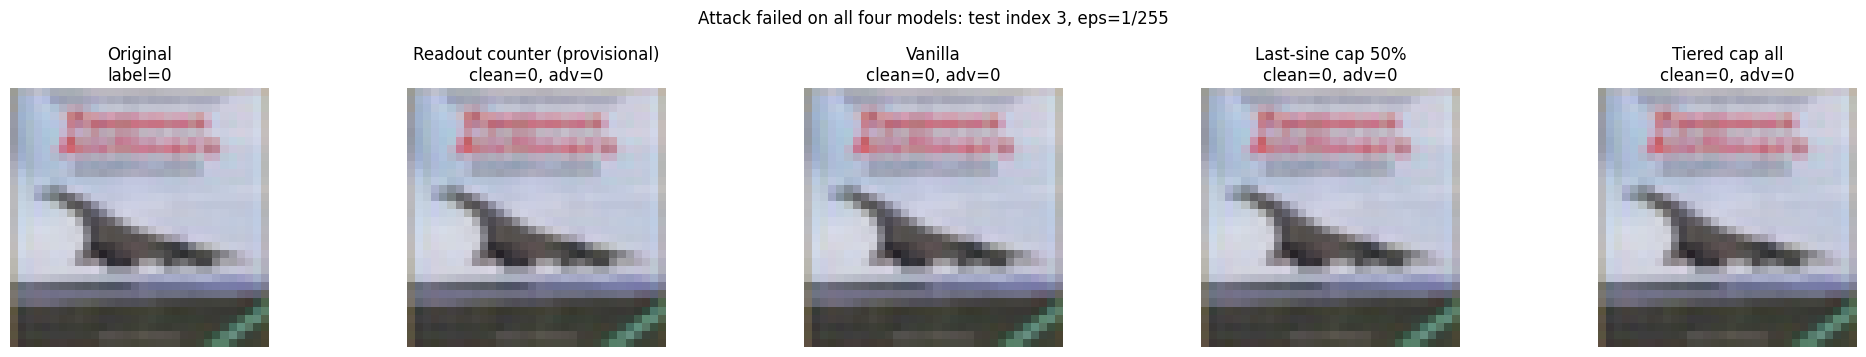

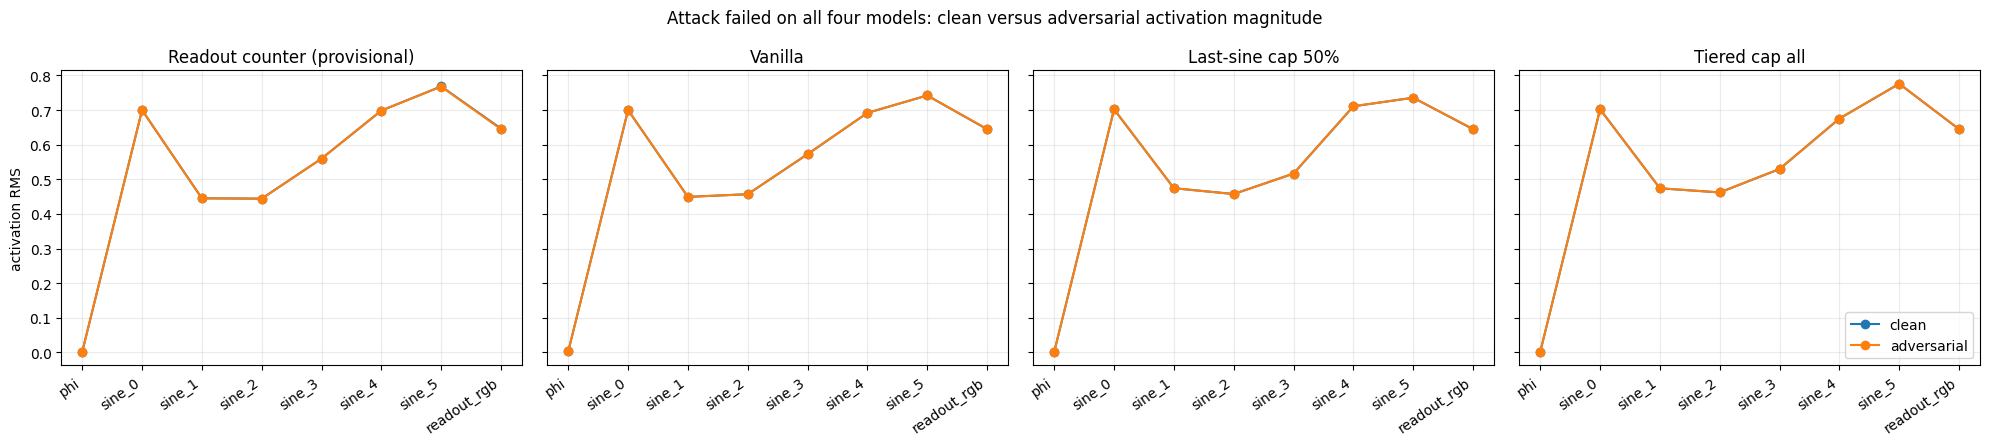

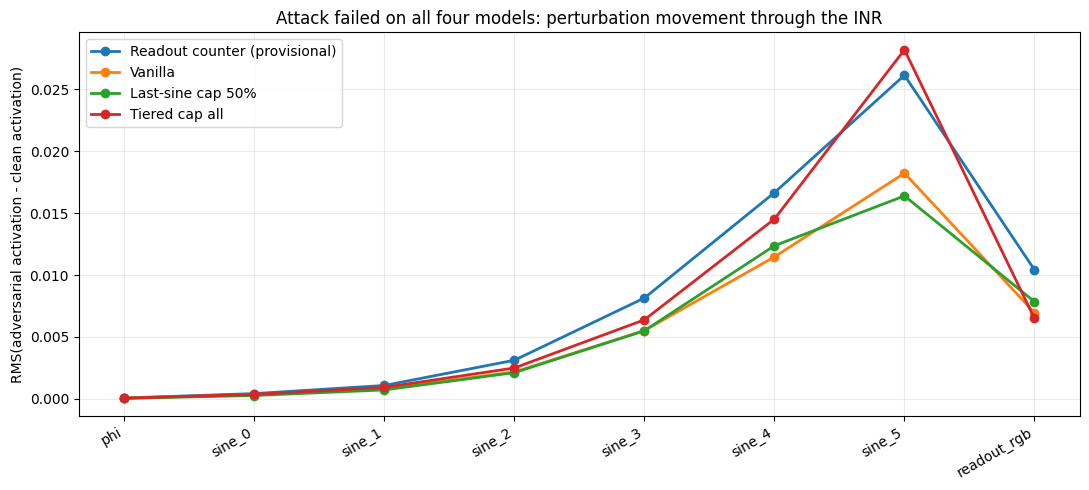

,model,layer,layer_index,clean_rms,adv_rms,difference_rms
0,Readout counter (provisional),phi,0,0.001552,0.001557,0.000071
1,Readout counter (provisional),sine_0,1,0.700093,0.700094,0.000426
2,Readout counter (provisional),sine_1,2,0.445069,0.445060,0.001082
3,Readout counter (provisional),sine_2,3,0.444172,0.444072,0.003122
4,Readout counter (provisional),sine_3,4,0.559816,0.559691,0.008149
5,Readout counter (provisional),sine_4,5,0.698610,0.698605,0.016659
6,Readout counter (provisional),sine_5,6,0.768435,0.767997,0.026143
7,Readout counter (provisional),readout_rgb,7,0.646635,0.644794,0.010420
8,Vanilla,phi,0,0.002522,0.002527,0.000063
9,Vanilla,sine_0,1,0.700132,0.700132,0.000344


In [4]:
def case_activation_frame(record):
    rows = []
    for display_name, result in record['results'].items():
        for layer_index, layer in enumerate(result['clean_activations']):
            clean_act = result['clean_activations'][layer]
            adv_act = result['adv_activations'][layer]
            rows.append({
                'model': display_name,
                'layer': layer,
                'layer_index': layer_index,
                'clean_rms': activation_rms(clean_act),
                'adv_rms': activation_rms(adv_act),
                'difference_rms': activation_rms(adv_act - clean_act),
            })
    return pd.DataFrame(rows)


def plot_joint_case(record, title):
    label = int(record['y'].item())
    x = record['x'][0].detach().cpu()
    frame = case_activation_frame(record)

    fig, axes = plt.subplots(1, 1 + len(record['results']), figsize=(4 * (1 + len(record['results'])), 3.6))
    axes[0].imshow(x.permute(1, 2, 0))
    axes[0].set_title(f'Original\nlabel={label}')
    axes[0].axis('off')
    for ax, (display_name, result) in zip(axes[1:], record['results'].items()):
        ax.imshow(result['adv_x'][0].detach().cpu().permute(1, 2, 0))
        ax.set_title(f"{display_name}\nclean={result['clean_pred']}, adv={result['adv_pred']}")
        ax.axis('off')
    fig.suptitle(f"{title}: test index {record['sample_index']}, eps={CASE_EPSILON_255}/255")
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, len(record['results']), figsize=(5 * len(record['results']), 4.5), sharey=True)
    for ax, (display_name, group) in zip(axes, frame.groupby('model', sort=False)):
        group = group.sort_values('layer_index')
        ax.plot(group['layer_index'], group['clean_rms'], marker='o', label='clean')
        ax.plot(group['layer_index'], group['adv_rms'], marker='o', label='adversarial')
        ax.set_xticks(group['layer_index'])
        ax.set_xticklabels(group['layer'], rotation=35, ha='right')
        ax.set_title(display_name)
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel('activation RMS')
    axes[-1].legend()
    fig.suptitle(f'{title}: clean versus adversarial activation magnitude')
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    for display_name, group in frame.groupby('model', sort=False):
        group = group.sort_values('layer_index')
        ax.plot(group['layer_index'], group['difference_rms'], marker='o', linewidth=2, label=display_name)
    first = frame.sort_values('layer_index').drop_duplicates('layer_index')
    ax.set_xticks(first['layer_index'])
    ax.set_xticklabels(first['layer'], rotation=30, ha='right')
    ax.set_ylabel('RMS(adversarial activation - clean activation)')
    ax.set_title(f'{title}: perturbation movement through the INR')
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    plt.show()
    display(frame)


plot_joint_case(failed_case, 'Attack failed on all four models')

## Cell 18: Plot A Joint Successful Attack

This uses exactly the same plotting code, but now all four pipelines were clean-correct and then fooled. Compare where the difference-RMS curves begin to separate from the failed-attack case.

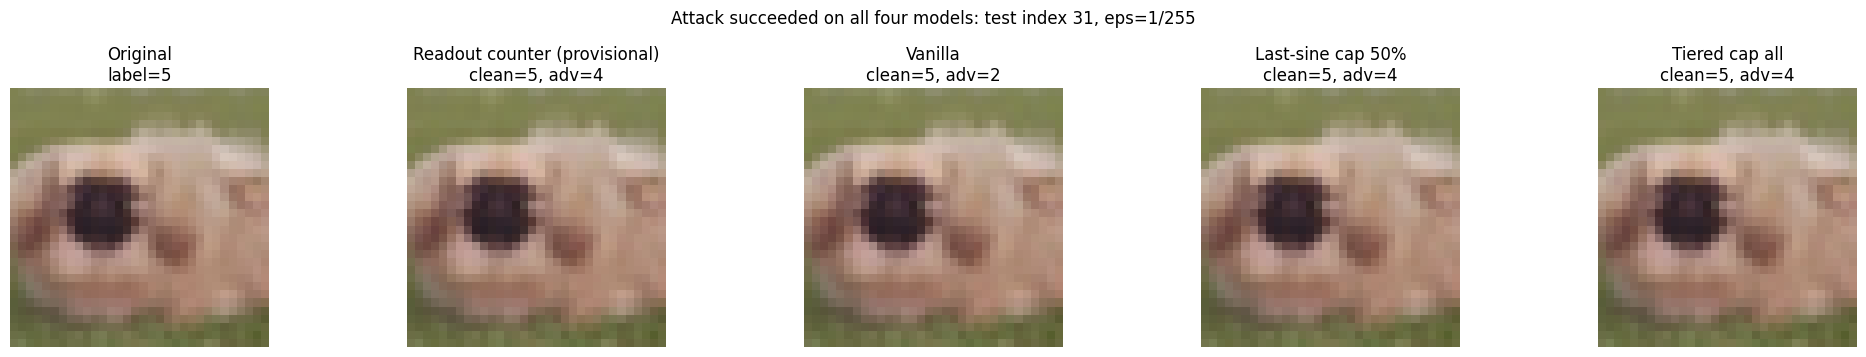

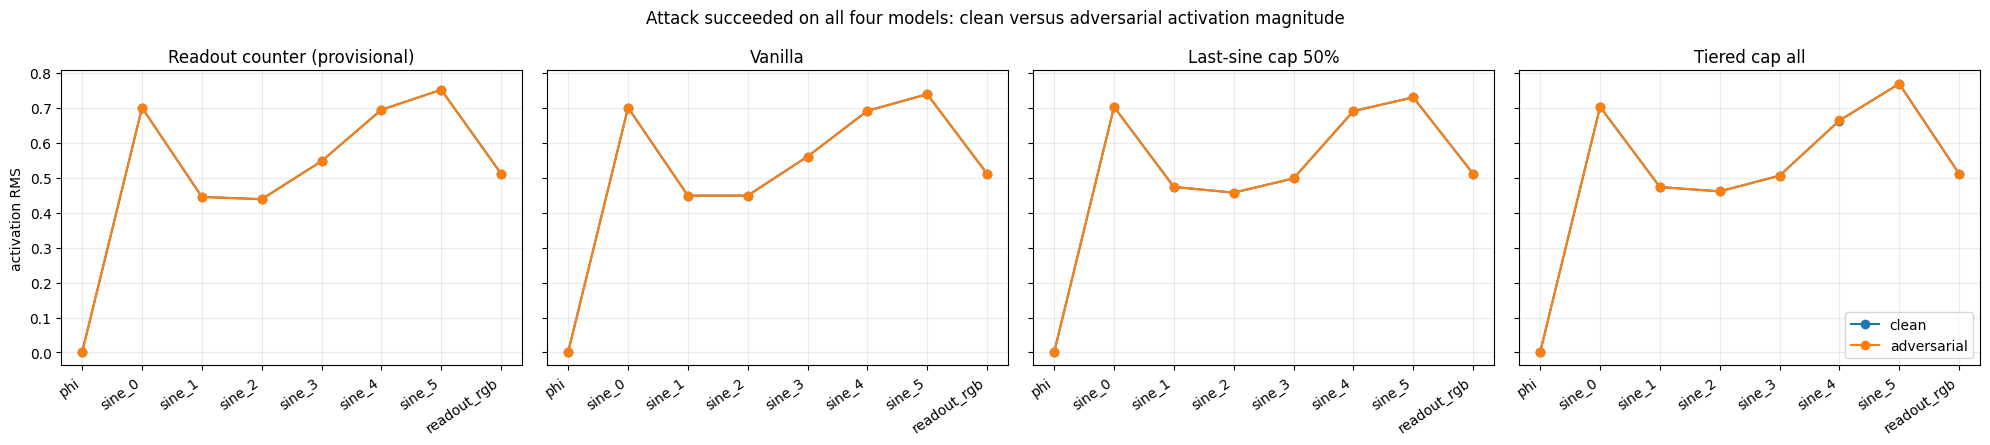

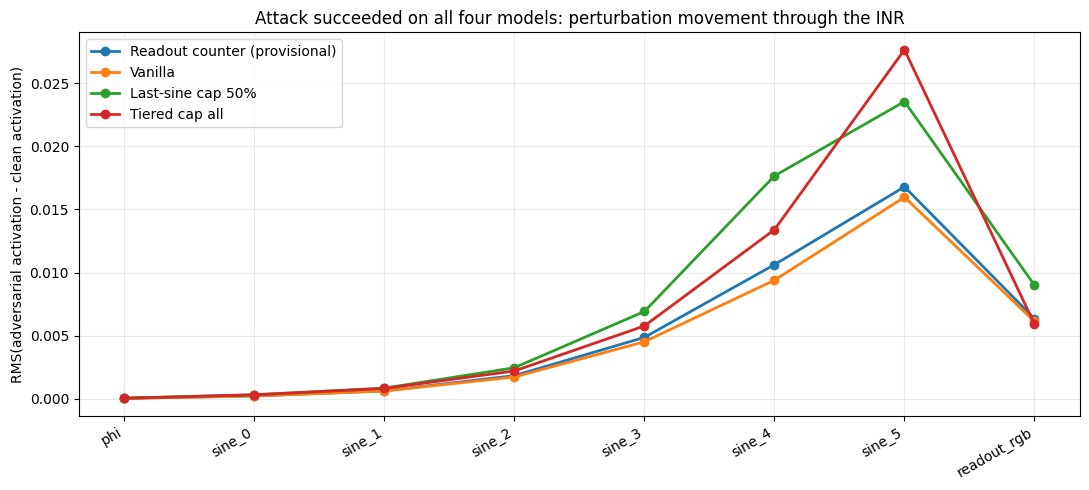

,model,layer,layer_index,clean_rms,adv_rms,difference_rms
0,Readout counter (provisional),phi,0,0.001842,0.001843,0.000034
1,Readout counter (provisional),sine_0,1,0.700139,0.700139,0.000229
2,Readout counter (provisional),sine_1,2,0.444879,0.444876,0.000624
3,Readout counter (provisional),sine_2,3,0.438355,0.438346,0.001835
4,Readout counter (provisional),sine_3,4,0.547143,0.547121,0.004864
5,Readout counter (provisional),sine_4,5,0.694060,0.694111,0.010627
6,Readout counter (provisional),sine_5,6,0.751333,0.751258,0.016795
7,Readout counter (provisional),readout_rgb,7,0.511808,0.511505,0.006345
8,Vanilla,phi,0,0.001972,0.001974,0.000034
9,Vanilla,sine_0,1,0.700155,0.700156,0.000217


In [5]:
plot_joint_case(succeeded_case, 'Attack succeeded on all four models')

## Cell 19: How To Decide Whether The Cap Worked

Read the focused plots in this order:

1. **Clean sample:** if the last-sine model has a smaller `sine_5` activation RMS while earlier layers remain similar, the cap changed the intended location without globally shrinking the network.
2. **Failed attack:** check whether the constrained models have smaller activation-difference RMS than vanilla, especially near `sine_5` and `readout_rgb`.
3. **Successful attack:** if the last-sine difference is smaller but all classifiers are still fooled, then reducing that late-layer movement was not sufficient for robustness.
4. **Tiered versus single-layer cap:** if tiered softlip reduces movement earlier in the SIREN, that supports the idea that amplification must be controlled across the full stack rather than only at the end.
5. **Phi row:** if the adversarial-clean difference is already large at `phi`, the instability is entering through the image-to-phi fitting map before the capped SIREN layer is reached.
